# Merge

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on merging a raster object.

The following librairies will be considered :
- `rasterio`
- `rioxarray`
- `odc-geo`
- `geoutils`

In [1]:
import numpy as np

import rasterio
from rasterio.merge import merge
from rasterio.plot import show

import rioxarray
from rioxarray.merge import merge_arrays

import geoutils as gu
from geoutils.raster import merge_rasters

import matplotlib.pyplot as plt

## Merge

Merge feature is implemented in `rasterio`, `rioxarray` and `geoutils` librairies, but not in `odc-geo`.

Merging is the process of combining multiple rasters into a single, continuous image. It can be useful to work on a uniform image for analysis, but also simplifies processing, visualization, storage etc.

In this notebook, we will show how to merge into one image the island of Sardinia that has been separated in two different rasters.

In [2]:
#path to the raster objects
rast1_path = "../data/rasters/sard1.tif"
rast2_path = "../data/rasters/sard2.tif"

### • rasterio

With rasterio, we will use the [.merge()](https://rasterio.readthedocs.io/en/stable/api/rasterio.merge.html) function:

As an argument to this function, we will pass the two opened dataset objects that we want to merge, so we will store them in a variable called `rasters_to_mosaic`:

In [ ]:
rasters = [rast1_path, rast2_path]

rasters_to_mosaic = [rasterio.open(r) for r in rasters]

Here is the first raster (North of Sardinia):

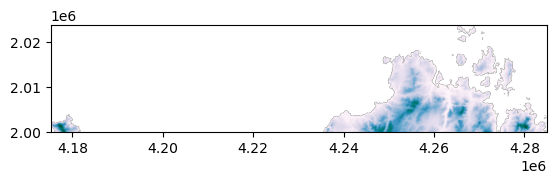

<Axes: >

In [ ]:
show(rasters_to_mosaic[1], cmap="PuBuGn")

And the second one (rest of the Sardinia island):

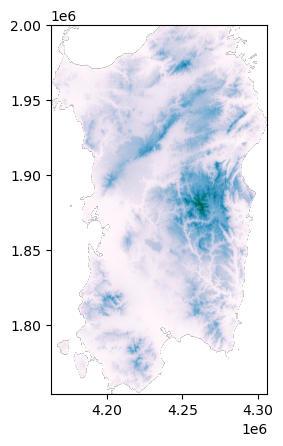

<Axes: >

In [ ]:
show(rasters_to_mosaic[0], cmap="PuBuGn")

We will then use the `merge` function. We will pass the list of our two opened rasters, and the nodata value we want to assign to our merged raster (`np.nan` in our case).

To be correcly merged, the input rasters must have the same number of bands, data type and CRS.

In [ ]:
rasterio_merged = merge(rasters_to_mosaic, nodata=np.nan)

The returned object is a tuple with two elements: a `numpy` array containing values of the input rasters, and the corresponding affine transformation matrix.

In [74]:
rasterio_merged

(array([[[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]]],
       shape=(1, 10785, 5761), dtype=float32),
 Affine(25.0, 0.0, 4162400.0,
        0.0, -25.0, 2023750.0))

We can finally plot the map, and confirm that the two different parts of Sardinia have been well merged:

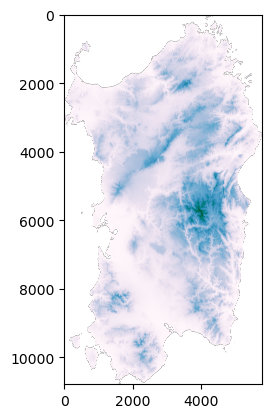

<Axes: >

In [77]:
show(rasterio_merged[0], cmap="PuBuGn")

### • rioxarray

Once again with `rioxarray`, we will create a mosaic with our two rasters to be merged:

In [56]:
rasters = [rast1_path, rast2_path]

rasters_to_mosaic = [rioxarray.open_rasterio(r) for r in rasters]

We can plot our two rasters:

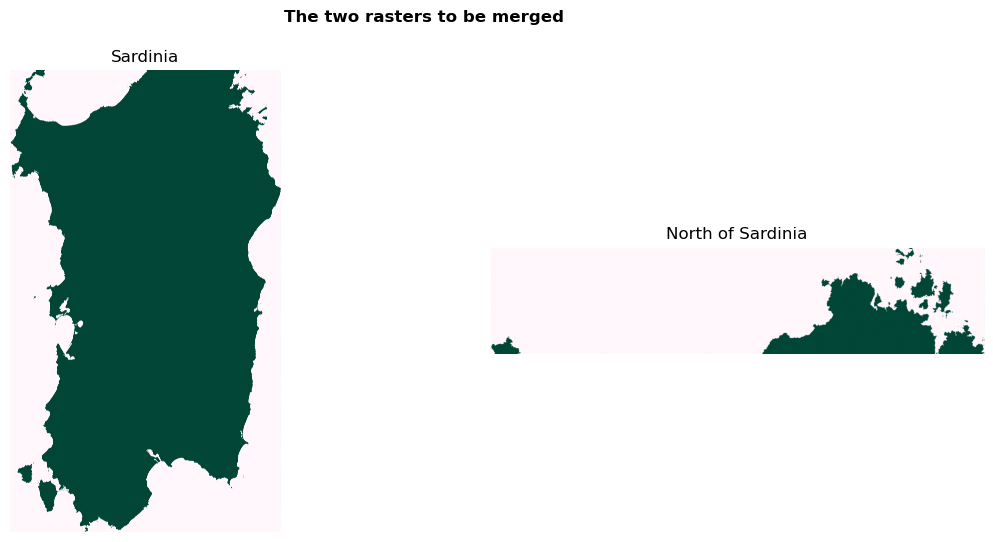

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle("The two rasters to be merged", fontweight="bold")

#sardinia
axes[0].imshow(rasters_to_mosaic[0].sel(band=1), cmap="PuBuGn")
axes[0].set_title("Sardinia")
axes[0].axis("off")

#north sardinia
axes[1].imshow(rasters_to_mosaic[1].sel(band=1), cmap="PuBuGn")
axes[1].set_title("North of Sardinia")
axes[1].axis("off")

plt.show()

We will use the [`merge_arrays()`](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.merge.merge_arrays) from `rioxarray`:

As an argument we just have to give the list of our two DataArrays to be merged:

In [59]:
rxr_merged = merge_arrays(rasters_to_mosaic)

We can plot the result and see that our rasters have been correctly merged together:

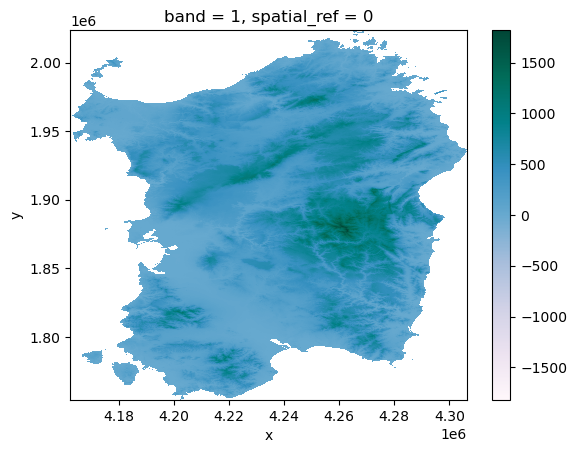

In [81]:
rxr_merged.where(rxr_merged!=rxr_merged.rio.nodata).plot(cmap="PuBuGn")

### • geoutils

With geoutils, we can simply use the [`merge_rasters()` function](https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.raster.merge_rasters.html):

We start by creating the mosaic:

In [61]:
rasters_to_mosaic = [gu.Raster(r) for r in rasters]

Here are the two `geoutils.Raster` objects we want to merge:

In [62]:
rasters_to_mosaic[0]

Raster(
  data=not_loaded; shape on disk (1, 9835, 5761); will load (9835, 5761)
  transform=| 25.00, 0.00, 4162400.00|
            | 0.00,-25.00, 2000000.00|
            | 0.00, 0.00, 1.00|
  crs=IGNF:ETRS89LAEA
  nodata=-3.4028234663852886e+38)

In [63]:
rasters_to_mosaic[1]

Raster(
  data=not_loaded; shape on disk (1, 950, 4389); will load (950, 4389)
  transform=| 25.00, 0.00, 4175200.00|
            | 0.00,-25.00, 2023750.00|
            | 0.00, 0.00, 1.00|
  crs=IGNF:ETRS89LAEA
  nodata=-3.4028234663852886e+38)

Unlike `rasterio`, the rasters to be merged can have a different transform or CRS, and a reference raster can be passed as an argument to be reprojected considering its parameters.

One thing to mention is that all rasters data will be loaded once in memory to be used for reprojection, and will be then deleted for memory usage.

Now we can call the `merge_rasters` function, and pass the list containing our rasters as an argument:

In [64]:
gu_merged = merge_rasters(rasters_to_mosaic)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:02<00:00,  1.08s/it]


And finally we can plot our merged raster:

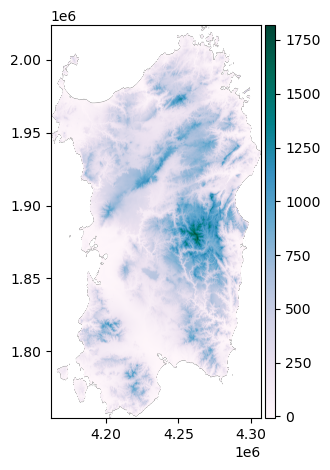

In [65]:
gu_merged.plot(cmap="PuBuGn")